# Initial Imports and Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os
import math

In [2]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [3]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 4* 0.0416667 # 1 hour to days

In [4]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Get data

In [5]:
TOI_id = 'TOI 1339'
search_result = lk.search_lightcurve(TOI_id, author='SPOC', exptime=120)
print(search_result)


SearchResult containing 28 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019   SPOC     120   269701147      0.0
  1 TESS Sector 16 2019   SPOC     120   269701147      0.0
  2 TESS Sector 17 2019   SPOC     120   269701147      0.0
  3 TESS Sector 18 2019   SPOC     120   269701147      0.0
  4 TESS Sector 19 2019   SPOC     120   269701147      0.0
  5 TESS Sector 21 2020   SPOC     120   269701147      0.0
  6 TESS Sector 22 2020   SPOC     120   269701147      0.0
  7 TESS Sector 24 2020   SPOC     120   269701147      0.0
  8 TESS Sector 25 2020   SPOC     120   269701147      0.0
...            ...  ...    ...     ...         ...      ...
 18 TESS Sector 73 2023   SPOC     120   269701147      0.0
 19 TESS Sector 75 2024   SPOC     120   269701147      0.0
 20 TESS Sector 76 2024   SPOC     120   269701147      0

In [6]:
lc_collection = search_result.download_all()
# lc_collection.plot()
# plt.show()
print(lc_collection)

LightCurveCollection of 28 objects:
    0: <TessLightCurve LABEL="TIC 269701147" SECTOR=15 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269701147" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 269701147" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 269701147" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 269701147" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 269701147" SECTOR=21 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 269701147" SECTOR=22 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 269701147" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 269701147" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 269701147" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 269701147

In [7]:
clean_lcs = [lc[lc.quality == 0] for lc in lc_collection]


In [8]:
# Normalize, flatten, and remove outliers
processed_lcs = [
    lc.normalize().flatten(window_length=1901).remove_outliers(sigma=5)
    for lc in clean_lcs
]

In [9]:
# Stitch into one combined light curve
combined_lc = processed_lcs[0]
for lc in processed_lcs[1:]:
    combined_lc = combined_lc.append(lc)



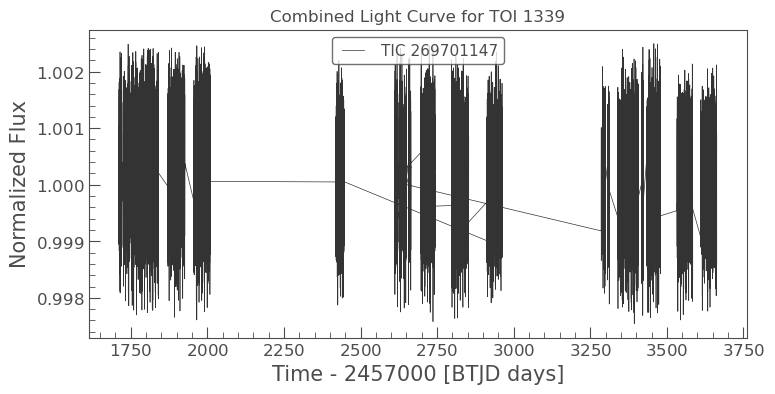

In [10]:
combined_lc.plot()
plt.title(f"Combined Light Curve for {TOI_id}")
plt.show()

In [11]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[1711.36577373 1711.36716265 1711.36855156 ... 3662.82380309 3662.82519195
 3662.82658081]
[1.00049623 0.9992364  1.00039897 ... 1.00009402 1.00046067 1.00058348]


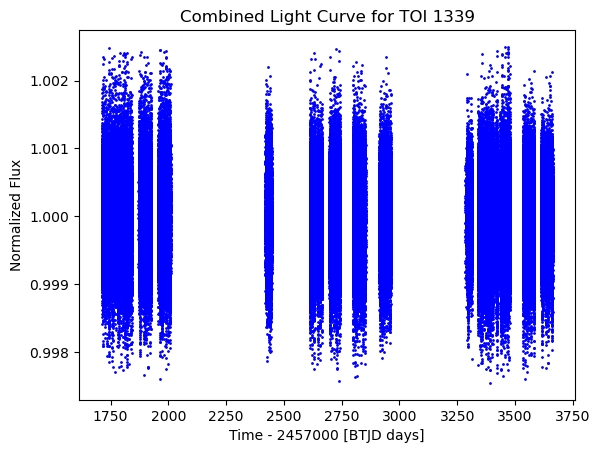

In [12]:
plt.scatter(time, flux, s=1, c='b')
plt.title(f'Combined Light Curve for {TOI_id}')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS Runs

## BLS 1

`period` contains 147250 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


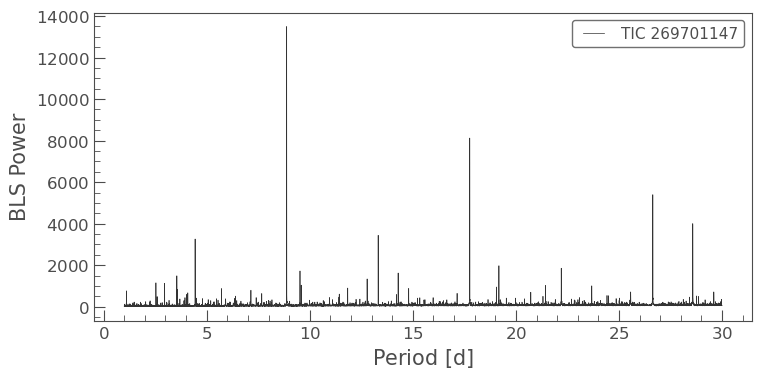

In [13]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(1, 30, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


In [14]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")
print(f"Best candidate dur: {planet_1_dur.value:.5f} days")

Best candidate period: 8.88009 days
Best candidate t0: 1715.38577 days
Best candidate dur: 0.10000 days


In [15]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*1.5)

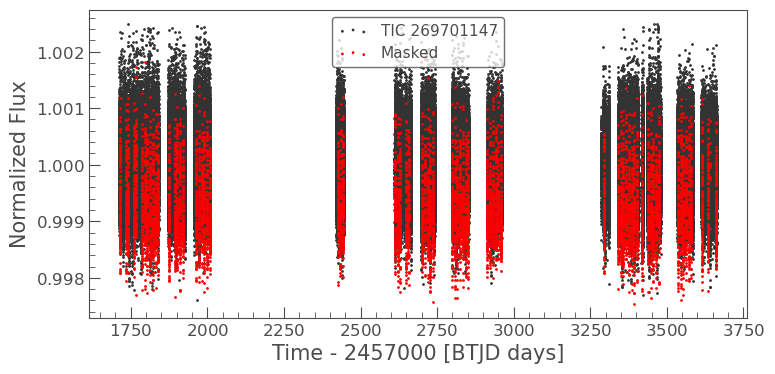

In [16]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [17]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


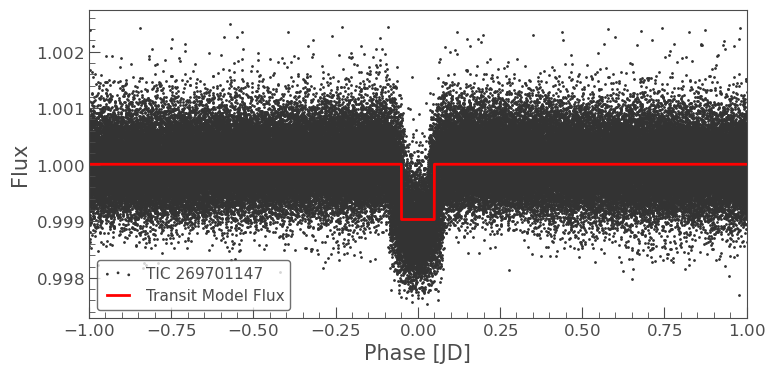

In [18]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


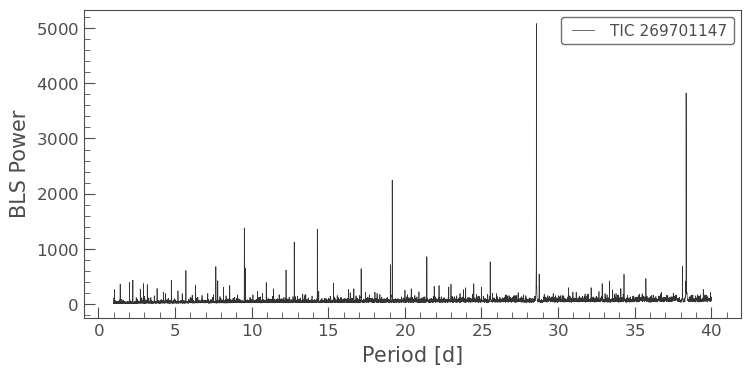

In [19]:
period = np.linspace(1, 40, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [20]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 28.57966 days
Best candidate t0 2: 1726.07077 days


In [21]:
# ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
# masked_lc_1.fold(planet_2_period, planet_2_t0).bin(.1).plot(ax=ax, c='r', lw=2,
#                                                           label='Binned Flux')
# ax.set_xlim(-5, 5)
# plt.show()

In [22]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*1.5)

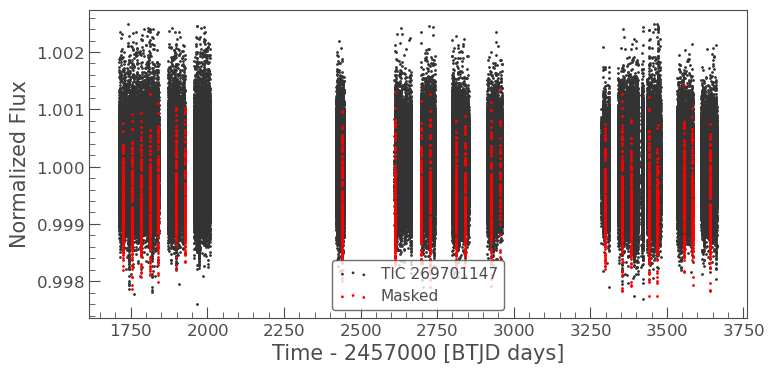

In [23]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [24]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

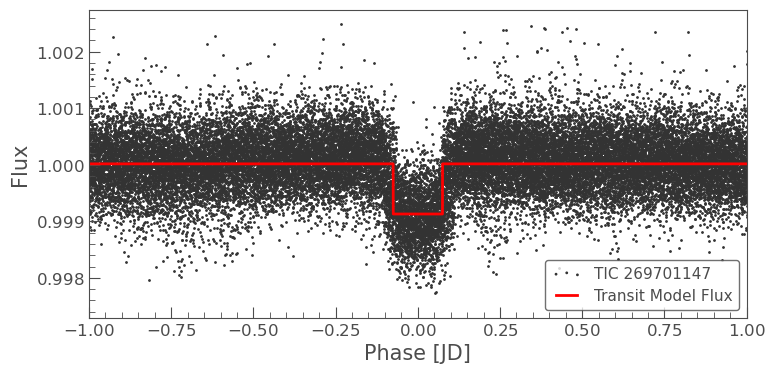

In [25]:
ax = combined_lc.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 3

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


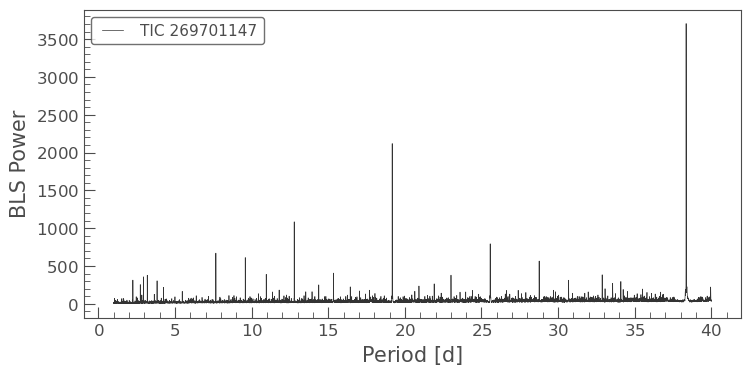

In [26]:
period = np.linspace(1, 40, 10000)
bls_3 = masked_lc_2.to_periodogram('bls', period=period, frequency_factor=500)
bls_3.plot()
plt.show()

In [27]:
planet_3_period = bls_3.period_at_max_power
planet_3_t0 = bls_3.transit_time_at_max_power
planet_3_dur = bls_3.duration_at_max_power

print(f"Best candidate period 3: {planet_3_period.value:.5f} days")
print(f"Best candidate t0 3: {planet_3_t0.value:.5f} days")

Best candidate period 3: 38.35014 days
Best candidate t0 3: 1743.60077 days


In [28]:
planet_3_mask = bls_3.get_transit_mask(period=planet_3_period,
                                     transit_time=planet_3_t0,
                                     duration=planet_3_dur*1.5)

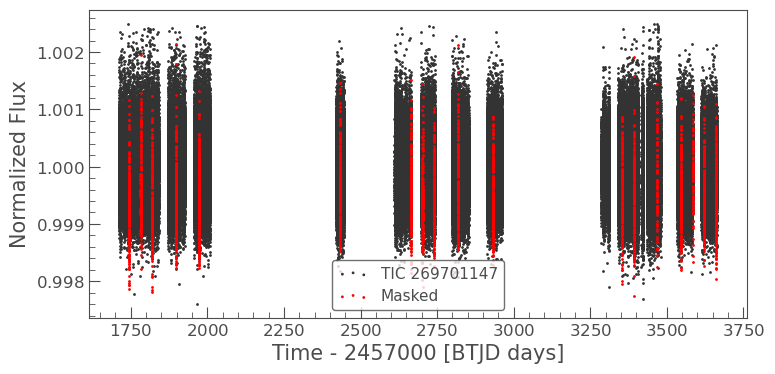

In [29]:
masked_lc_3 = masked_lc_2[~planet_3_mask]
ax = masked_lc_3.scatter();
masked_lc_2[planet_3_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [30]:
planet_3_model = bls_3.get_transit_model(period=planet_3_period,
                                       transit_time=planet_3_t0,
                                       duration=planet_3_dur)

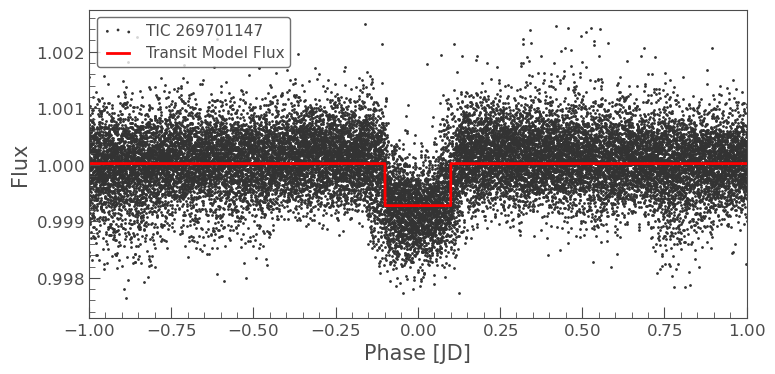

In [31]:
ax = combined_lc.fold(planet_3_period, planet_3_t0).scatter()
planet_3_model.fold(planet_3_period, planet_3_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## Transit models

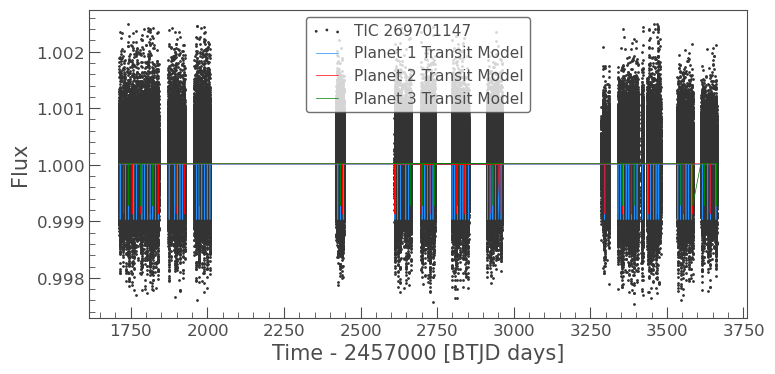

In [32]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
planet_3_model.plot(ax=ax, c='g', label='Planet 3 Transit Model');
# planet_4_model.plot(ax=ax, c='purple', label='Planet 4 Transit Model');
# planet_5_model.plot(ax=ax, c='orange', label='Planet 5? Transit Model');
# planet_6_model.plot(ax=ax, c='pink', label='Planet 6 Transit Model');

# plt.xlim(1340,1345)
# plt.ylim(0.998,1.002)
plt.show()

## Finding transit guess times based on models 

In [33]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = planet_1_model.time.value[peaks_1]
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_1, fluxes_1):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_1)

Planet 1 transit dip times and depths:
[1715.38527704 1733.14523276 1742.02587491 1759.78567928 1768.66761612
 1786.4258593  1795.30633585 1804.18539619 1813.06580968 1821.94620939
 1830.82659697 1839.70835103 1875.22701533 1892.98638832 1901.86679936
 1910.7472269  1919.62767918 1964.02758268 1972.90820848 1981.78885672
 1990.66813566 1999.54883028 2008.42815048 2425.79153607 2434.67226022
 2443.55296614 2940.83690204 2949.71726739 2958.59762072 2914.19716427
 2923.07756003 2931.95654011 2825.39607959 2834.27672658 2843.15595796
 2852.03656006 2798.75539797 2807.63611065 2816.51540916 2718.83444273
 2727.71512723 2736.59582888 2701.07452772 2709.95377835 2647.79543122
 2656.67451159 2612.27377137 2621.1541622  2630.03455845 3296.0411228
 3340.44153921 3349.32191666 3358.20092089 3367.08134645 3375.96316842
 3384.84224467 3393.72135527 3402.60186901 3420.36255094 3438.12240868
 3447.00167214 3455.88235194 3464.76305999 3473.64237797 3535.80333204
 3544.68264565 3553.56331552 3562.44396

In [34]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = planet_2_model.time.value[peaks_2]
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

Planet 2 transit dip times and depths:
[1726.07015657 1754.64955949 1783.22866248 1811.8088851  1840.38889302
 1897.54881426 1926.1276247  2440.56124822 2955.05602988 2926.41637574
 2840.67816668 2812.0972907  2726.35816013 2697.77866723 2612.03905394
 3297.9508079  3355.110701   3383.69086794 3440.8502093  3469.42980131
 3555.16750387 3583.74827239 3640.90754888]


In [35]:
# Find all local minima (i.e., transit dips)
peaks_3, _ = find_peaks(-planet_3_model.flux.value, prominence=1e-5)
transit_times_3 = planet_3_model.time.value[peaks_3]
fluxes_3 = planet_3_model.flux.value[peaks_3]

print("Planet 3 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_3)

Planet 3 transit dip times and depths:
[1743.59949615 1781.95228358 1820.30040791 1897.00021101 1973.70127038
 2433.90280344 2932.45375239 2817.40431107 2740.70423947 2702.35370661
 2664.005026   3354.30516178 3392.65608153 3469.28674339 3546.05627803
 3584.34133025 3622.75642463 3661.10717036]


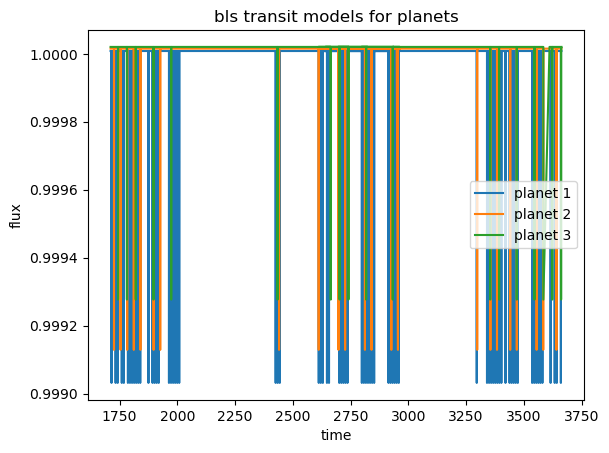

In [36]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')
plt.plot(planet_3_model.time.value, planet_3_model.flux.value, label='planet 3')
# plt.plot(planet_4_model.time.value, planet_4_model.flux.value, label='planet 4')
# plt.plot(planet_5_model.time.value, planet_5_model.flux.value, label='planet 5?')
# plt.plot(planet_6_model.time.value, planet_6_model.flux.value, label='planet 6?')

# plt.xlim(1335,1345)
# plt.xlim(1330,1350)
# plt.xlim(2100,2200)
# plt.xlim(1377,1380)
plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Fit Transit Times

In [37]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

## Definitions

In [38]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [39]:

def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
        ### fit parabola to the chisq
        p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  
    
        ### Extract the coefficients   y = ax^2 + bx + c
        a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
        
        ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
        tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
        
        ### Calculate the minimum chi-squared value
        chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
        tc_chi_parabola[j] = tc_best_fit
    
        ### Calculate the parabola best fit 
        p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq
    
        ### calculate ttv from parabola fit 
        ttv_p[j] = tc_best_fit - tc_guess[j]
    
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # # Find the intersection using root_scalar
        # intersections = []
        # for k in range(len(tc1) - 1):
        #     if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections.append((sol.root - min_chi_time))
        # errors.append(intersections)
    
        # intersections_p = []
        # for k in range(len(tc1) - 1):
        #     if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections_p.append((sol.root - tc_best_fit))
        # errors_p.append(intersections_p)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, ttv

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [41]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [42]:
### stellar params
q1 = 0.304
q2 = 0.40

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(u1)
print(u2)

0.44108956006688715
0.11027239001672175


## Planet 1

In [43]:
### Planet params (from exoplanet archive Gilbert et al 2023)
# planet b
per_1=  8.8803256
rp_1= 0.03319
b_1=  0.610
T14_1= 2.939 * 0.0416667  # convert to days from hours 


In [44]:
tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [45]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
tc_chi_parabola = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
ttv_p = np.zeros(len(tc_1))
errors = []
errors_p = []

In [46]:
tc_chi_1, ttv_1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

In [47]:
print(tc_chi_1)

[1715.35541382 1733.11770521 1741.99667902 1759.75948639 1768.66578095
 1786.39933275 1795.28281231 1804.16120531 1813.04128514 1821.91667984
 1830.80240609 1839.67948881 1875.20382545 1892.96353212 1901.84294215
 1910.72437069 1919.6014863  1964.00172347 1972.8840176  1981.77234019
 1990.64628045 1999.52630774 2008.40395961 2425.78236022 2434.6657537
 2443.54011995 2940.84240755 2949.7277779  2958.60479457 2914.19866578
 2923.07772686 2931.95737428 2825.39724742 2834.27756075 2843.15712579
 2852.03605956 2798.7535628  2807.63160614 2816.514575   2718.83294123
 2727.71229106 2736.5929927  2701.07102421 2709.95160951 2647.78925837
 2656.66900608 2612.26593019 2621.1526607  2630.02604994 3296.05230065
 3340.4523834  3349.33442919 3358.21376708 3367.09752931 3375.97601461
 3384.85776019 3393.73720446 3402.61838554 3420.37606446 3438.13959255
 3447.01818867 3455.8995358  3464.78091118 3473.66356584 3535.82385258
 3544.70049684 3553.58183405 3562.46315152 3571.34473635 3580.22332936
 3615.7

In [48]:
### after inspection of single transits
values_to_remove_1 = [1768.66578095, 2709.95160951, 3633.50724503, 3642.20057878]
# Define a tolerance level (adjust if needed)
tolerance = 1e-6

# tc_chi_1 = [x for x in tc_chi_1 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_1)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_1_cleaned = []
ttv_1_cleaned = []

for i in range(len(tc_chi_1)):
    if not any(math.isclose(tc_chi_1[i], val, abs_tol=tolerance) for val in values_to_remove_1):
        tc_chi_1_cleaned.append(tc_chi_1[i])
        ttv_1_cleaned.append(ttv_1[i])

# Overwrite the originals if needed
tc_chi_1 = tc_chi_1_cleaned
ttv_1 = ttv_1_cleaned
print("Modified List (after removal):", tc_chi_1)


Modified List (after removal): [1715.3554138170766, 1733.1177052058397, 1741.9966790217254, 1759.7594863949794, 1786.3993327524447, 1795.282812306814, 1804.1612053097028, 1813.0412851350552, 1821.916679839008, 1830.8024060885173, 1839.679488809774, 1875.2038254524273, 1892.9635321154021, 1901.8429421464, 1910.7243706894353, 1919.6014862983075, 1964.0017234662705, 1972.8840175983191, 1981.772340191726, 1990.6462804508126, 1999.5263077432971, 2008.4039596061257, 2425.7823602178973, 2434.665753703352, 2443.5401199500425, 2940.8424075548396, 2949.727777904308, 2958.6047945664563, 2914.1986657751954, 2923.0777268631805, 2931.957374276408, 2825.39724742401, 2834.27756074832, 2843.1571257919904, 2852.0360595551683, 2798.753562798274, 2807.631606144323, 2816.5145749951785, 2718.832941229813, 2727.7122910625912, 2736.5929927033103, 2701.071024209959, 2647.78925837366, 2656.6690060789174, 2612.2659301853823, 2621.1526606995917, 2630.026049936838, 3296.0523006529143, 3340.452383395677, 3349.33442

In [49]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = tc_chi_1

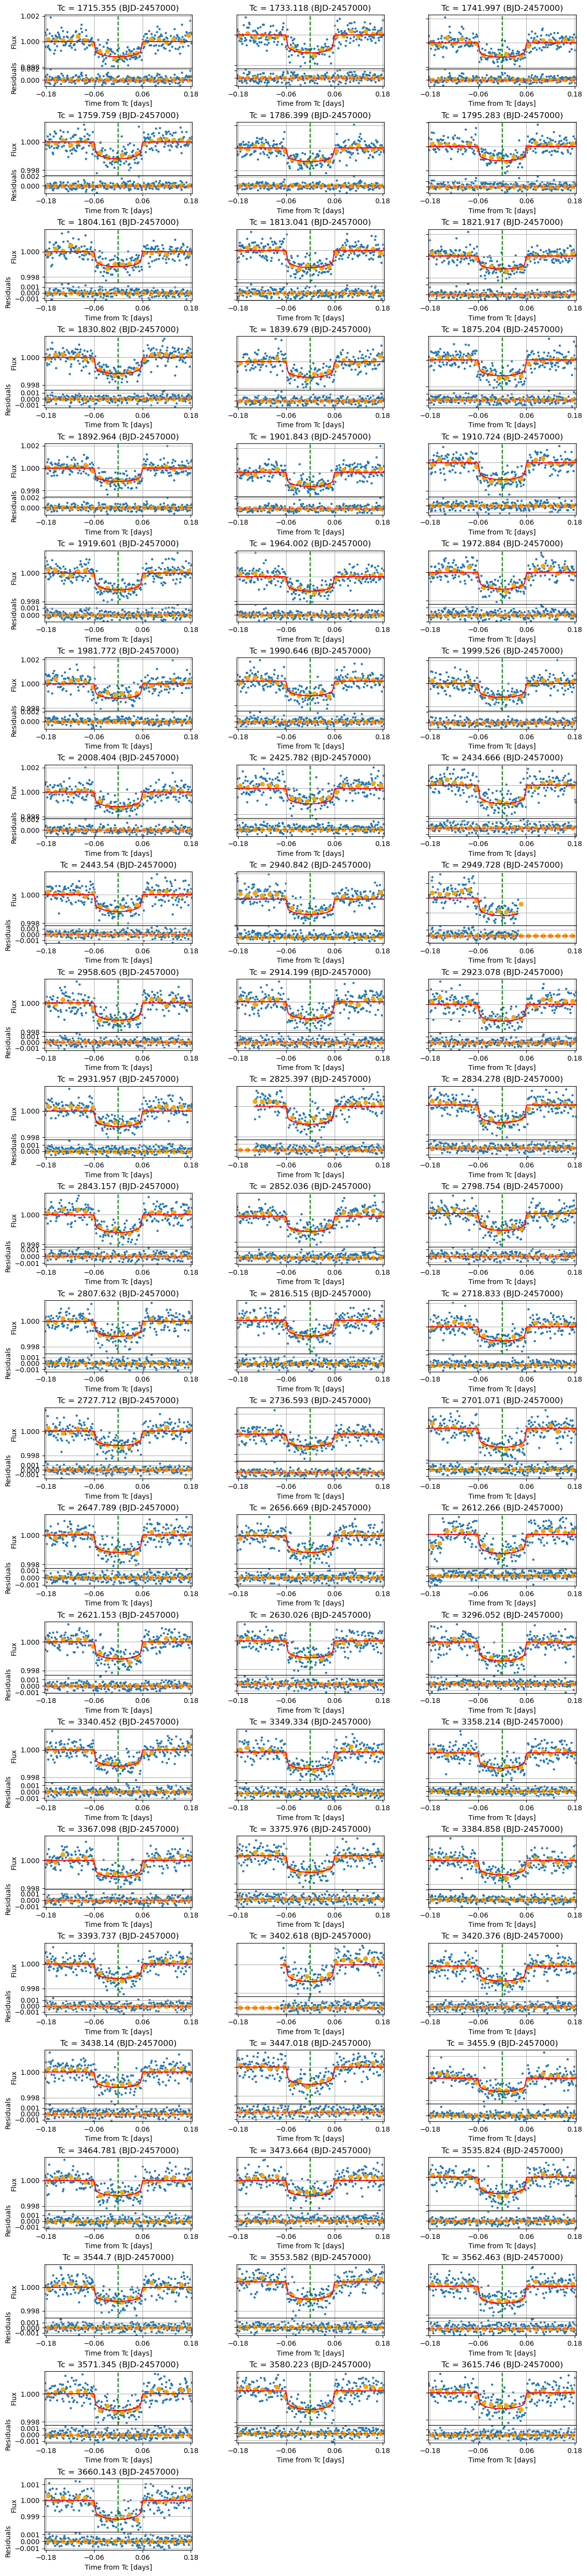

In [50]:
plot_transits(transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

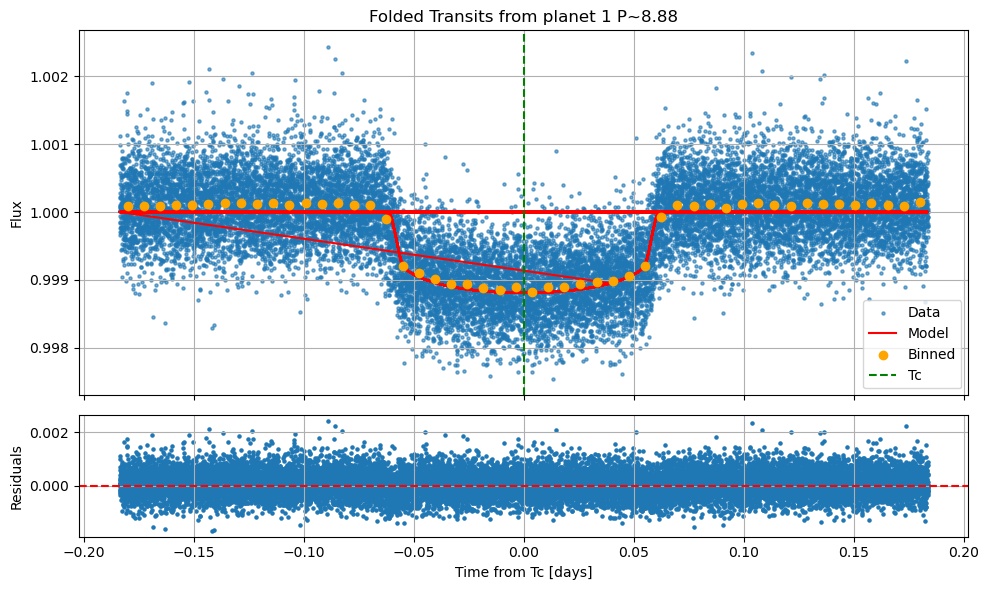

In [51]:
plot_folded_from_transits(transit_times_1, time, flux, per_1, rp_1, b_1, T14_1, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 1 P~{round(planet_1_period.value, 3)}')

## Planet 2

In [52]:
### Planet params (from barros et al 2022)
# planet b
per_2=  28.579743
rp_2= 0.03118
b_2=  0.630
T14_2= 4.162 * 0.0416667  # convert to days from hours 


In [53]:
tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - ttv_hour
    end = tc_guess_2[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [54]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
tc_chi_parabola = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
ttv_p = np.zeros(len(tc_2))
errors = []
errors_p = []

In [55]:
tc_chi_2, ttv_2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

In [56]:
print(tc_chi_2)

[1726.05230537 1754.6317083  1783.20780828 1811.79770725 1840.37904984
 1897.53830374 1926.12078452 2440.54139502 2954.99780495 2926.42721993
 2840.67099284 2812.0987922  2726.35499029 2697.77616473 2612.03087909
 3297.97533244 3355.1265502  3383.70371413 3440.87606851 3469.42362847
 3555.19202841 3583.77179593 3640.92907042]


In [57]:
### after inspection of single transits
values_to_remove_2 = [2954.99780495, 3469.42362847]
# Define a tolerance level (adjust if needed)
tolerance = 1e-6

# tc_chi_2 = [x for x in tc_chi_2 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_2)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_2_cleaned = []
ttv_2_cleaned = []

for i in range(len(tc_chi_2)):
    if not any(math.isclose(tc_chi_2[i], val, abs_tol=tolerance) for val in values_to_remove_2):
        tc_chi_2_cleaned.append(tc_chi_2[i])
        ttv_2_cleaned.append(ttv_2[i])

# Overwrite the originals if needed
tc_chi_2 = tc_chi_2_cleaned
ttv_2 = ttv_2_cleaned
print("Modified List (after removal):", tc_chi_2)


Modified List (after removal): [1726.0523053710463, 1754.631708295026, 1783.207808278371, 1811.7977072487533, 1840.3790498376009, 1897.5383037442973, 1926.120784518578, 2440.5413950174407, 2926.427219926762, 2840.6709928374466, 2812.0987921984606, 2726.3549902906316, 2697.776164728058, 2612.030879088145, 3297.975332441588, 3355.126550196479, 3383.7037141332803, 3440.8760685135303, 3555.1920284121047, 3583.7717959299225, 3640.929070419659]


In [58]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = tc_chi_2

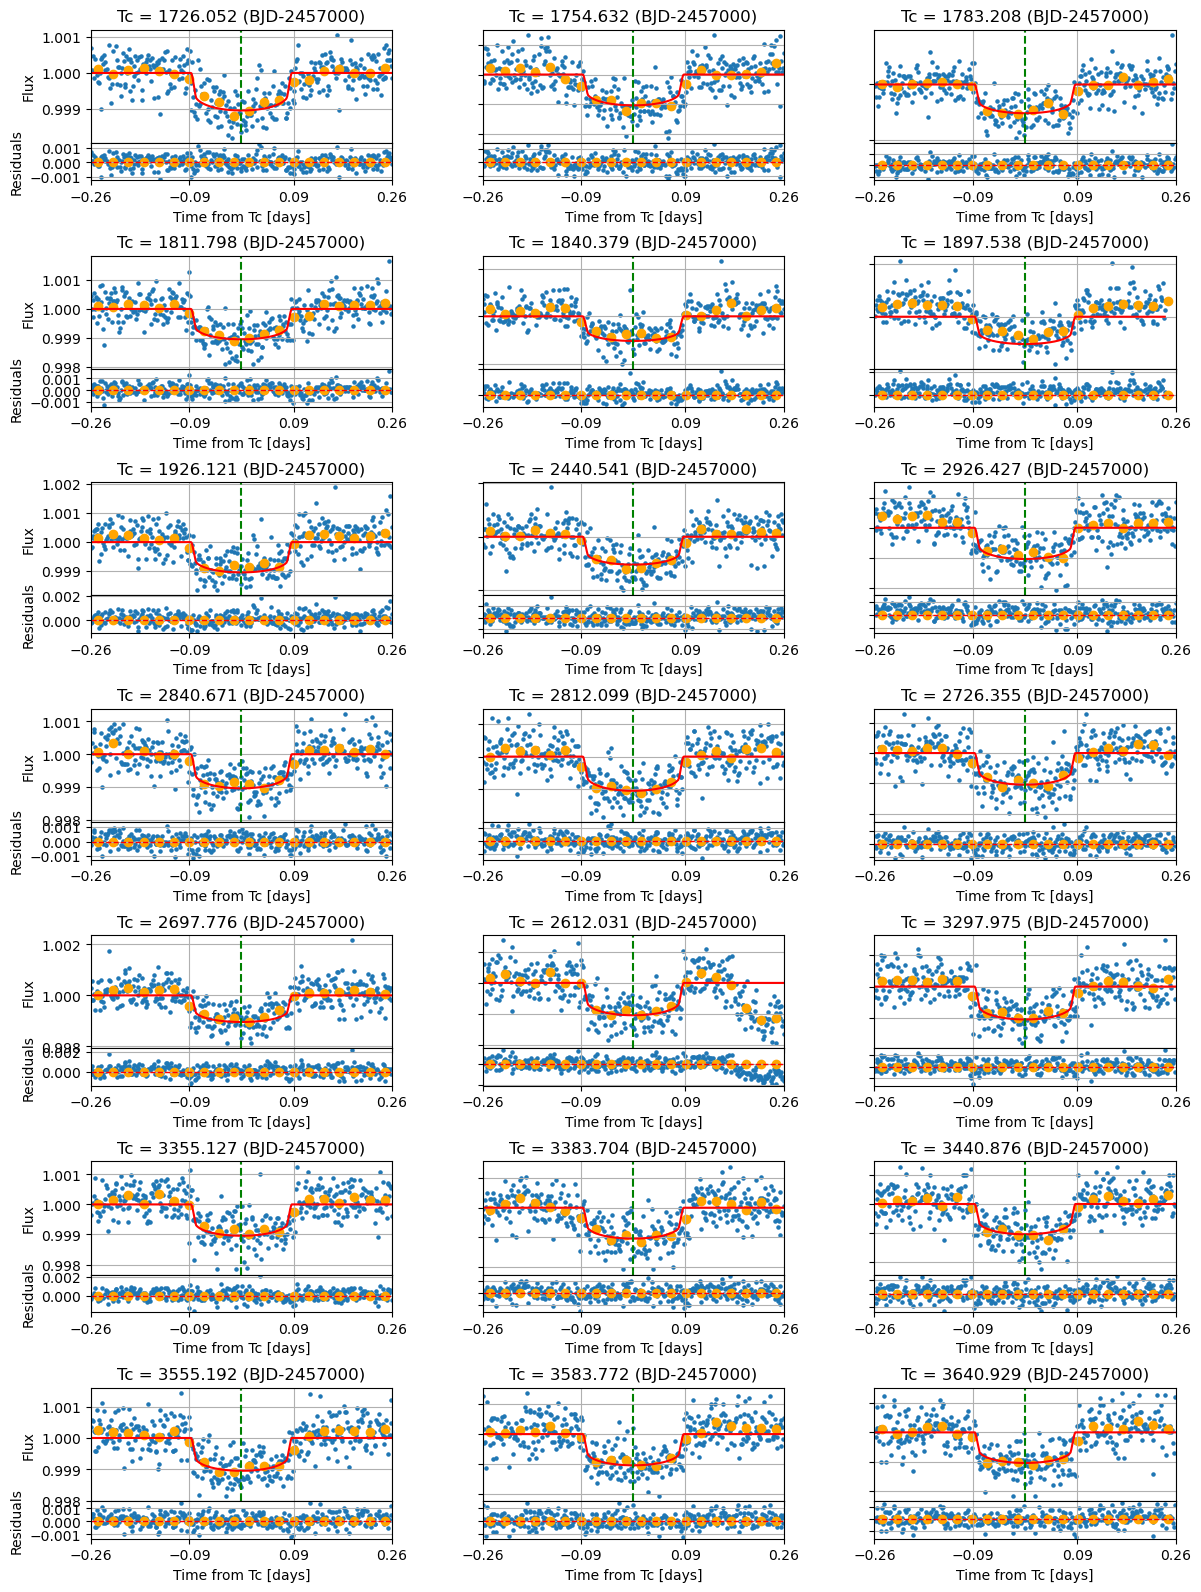

In [59]:
plot_transits(transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)

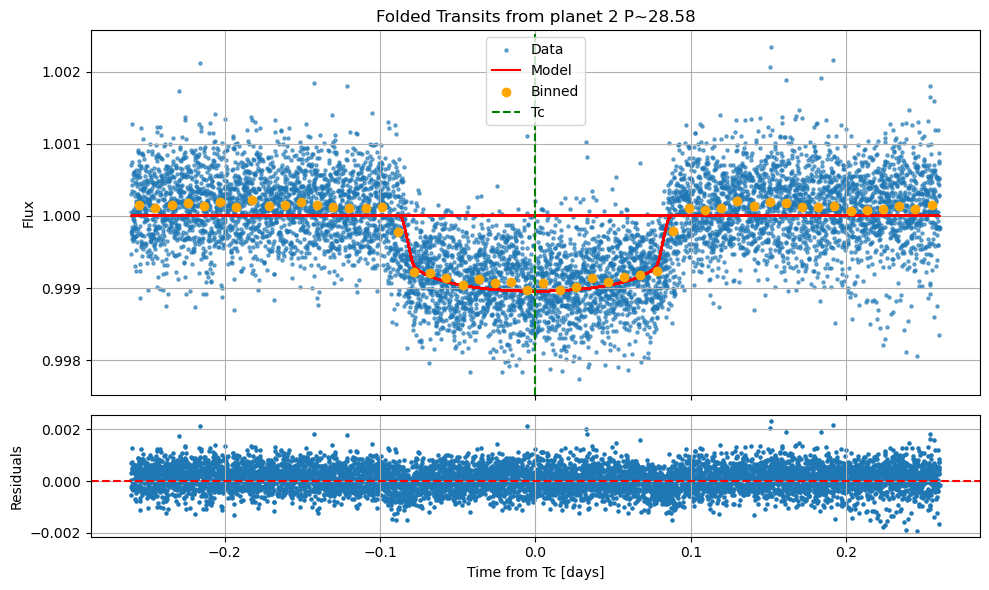

In [60]:
plot_folded_from_transits(transit_times_2, time, flux, per_2, rp_2, b_2, T14_2, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 2 P~{round(planet_2_period.value, 3)}')

## Planet 3

In [61]:
### Planet params (from barros et al 2022)
# planet b
per_3=  38.353037
rp_3=  0.02916
b_3=  0.440
T14_3= 5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [62]:
tc_guess_3 = transit_times_3
### get tc ranges for fit
tc_3 = []
for i in range(len(tc_guess_3)):
    start = tc_guess_3[i] - ttv_hour
    end = tc_guess_3[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_3.append(t)

In [63]:
### initialize arrays
tc_chi = np.zeros(len(tc_3))
tc_chi_parabola = np.zeros(len(tc_3))
ttv = np.zeros(len(tc_3))
ttv_p = np.zeros(len(tc_3))
errors = []
errors_p = []

In [64]:
tc_chi_3, ttv_3 = plot_chi_sq(time, flux, flux_err, tc_3, tc_guess_3, per_3, rp_3, b_3, T14_3, u1, u2)

In [65]:
print(tc_chi_3)

[1743.55495157 1781.90373499 1820.26520602 1896.96033777 1973.66506748
 2433.91665064 2932.4622609  2817.41048391 2740.71474999 2702.35253878
 2664.02254353 3354.30032361 3392.66192071 3469.35964969 3546.07312822
 3584.43525759 3622.76626781 3661.1276909 ]


In [66]:
### after inspection of single transits
values_to_remove_3 = [3469.35964969, 3584.43525759]
# Define a tolerance level (adjust if needed)
tolerance = 1e-6

# tc_chi_3 = [x for x in tc_chi_3 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_3)]

# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_3_cleaned = []
ttv_3_cleaned = []

for i in range(len(tc_chi_3)):
    if not any(math.isclose(tc_chi_3[i], val, abs_tol=tolerance) for val in values_to_remove_3):
        tc_chi_3_cleaned.append(tc_chi_3[i])
        ttv_3_cleaned.append(ttv_3[i])

# Overwrite the originals if needed
tc_chi_3 = tc_chi_3_cleaned
ttv_3 = ttv_3_cleaned


print("Modified List (after removal):", tc_chi_3)


Modified List (after removal): [1743.5549515650207, 1781.9037349904463, 1820.2652060175265, 1896.9603377736353, 1973.6650674805467, 2433.9166506358474, 2932.462260903496, 2817.4104839147385, 2740.7147499868743, 2702.352538776791, 2664.0225435336465, 3354.3003236080353, 3392.6619207076765, 3546.073128223445, 3622.766267812653, 3661.127690895217]


In [67]:
# Transit windows
buffer = 1.5 * T14_3
transit_times_3 = tc_chi_3

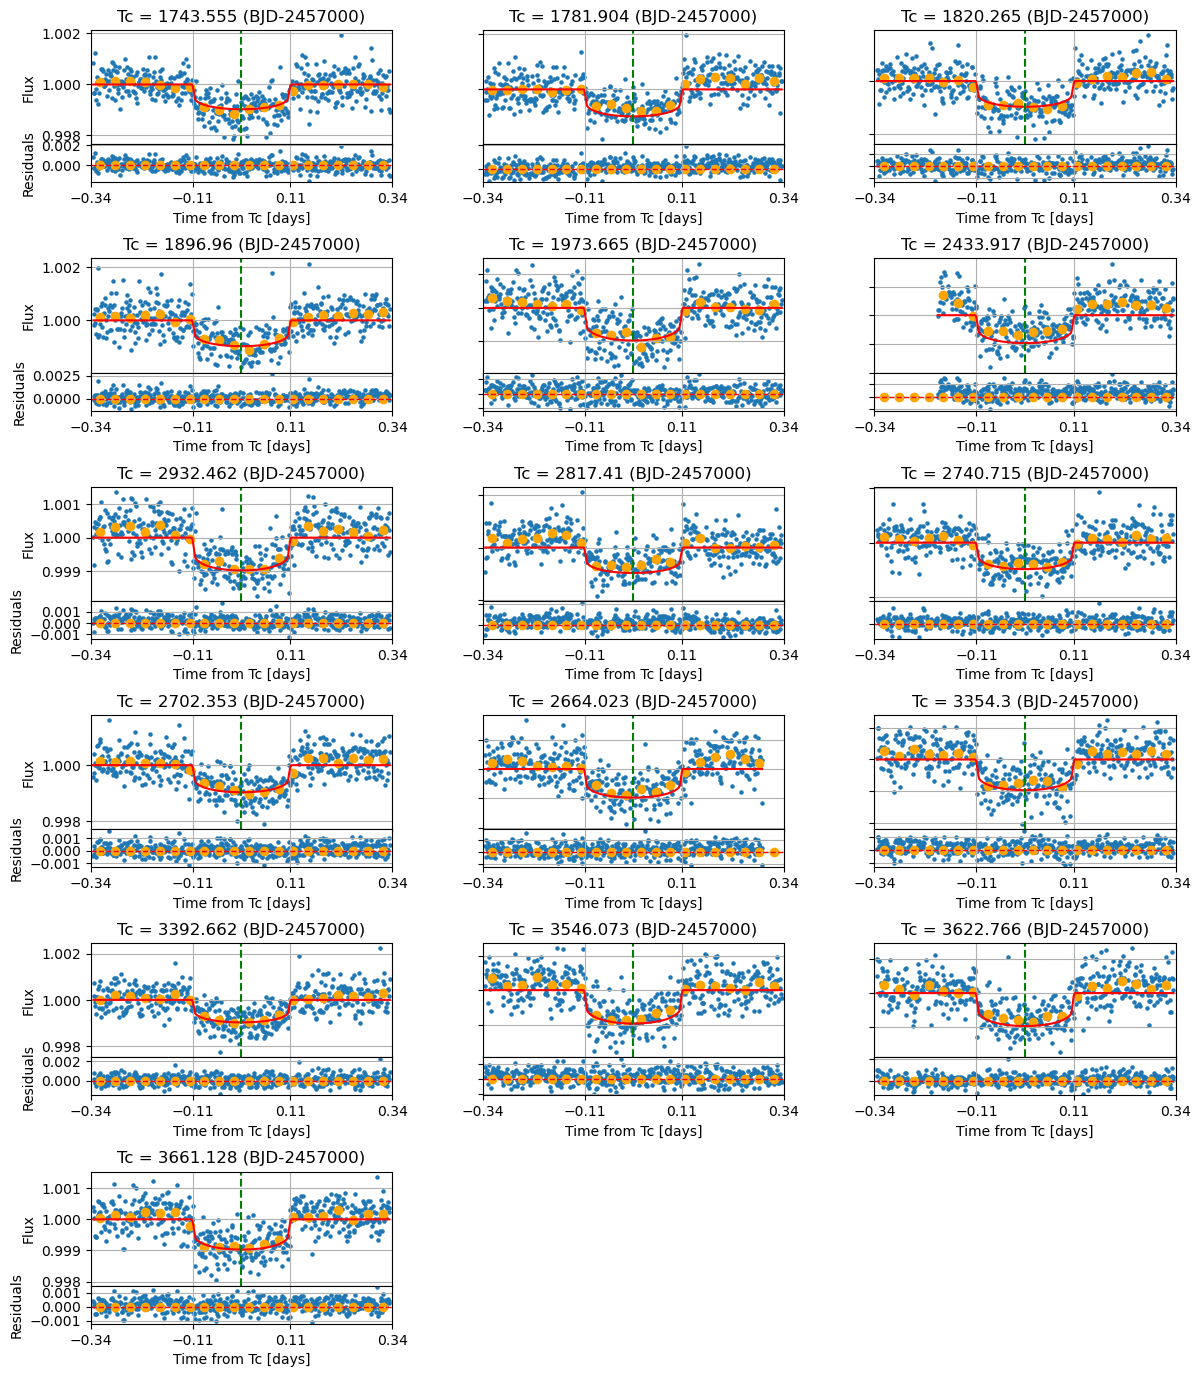

In [68]:
plot_transits(transit_times_3, per_3, rp_3, b_3, T14_3, u1, u2)

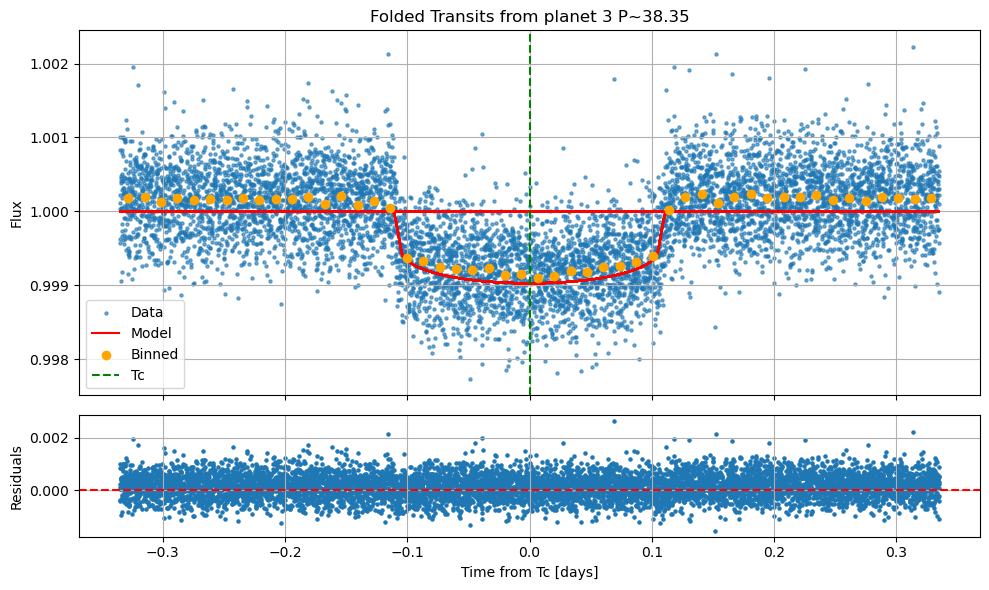

In [69]:
plot_folded_from_transits(transit_times_3, time, flux, per_3, rp_3, b_3, T14_3, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 3 P~{round(planet_3_period.value, 3)}')

In [70]:
print(np.sort(tc_chi_2))
print(np.sort(tc_chi_3))

[1726.05230537 1754.6317083  1783.20780828 1811.79770725 1840.37904984
 1897.53830374 1926.12078452 2440.54139502 2612.03087909 2697.77616473
 2726.35499029 2812.0987922  2840.67099284 2926.42721993 3297.97533244
 3355.1265502  3383.70371413 3440.87606851 3555.19202841 3583.77179593
 3640.92907042]
[1743.55495157 1781.90373499 1820.26520602 1896.96033777 1973.66506748
 2433.91665064 2664.02254353 2702.35253878 2740.71474999 2817.41048391
 2932.4622609  3354.30032361 3392.66192071 3546.07312822 3622.76626781
 3661.1276909 ]


# O-C

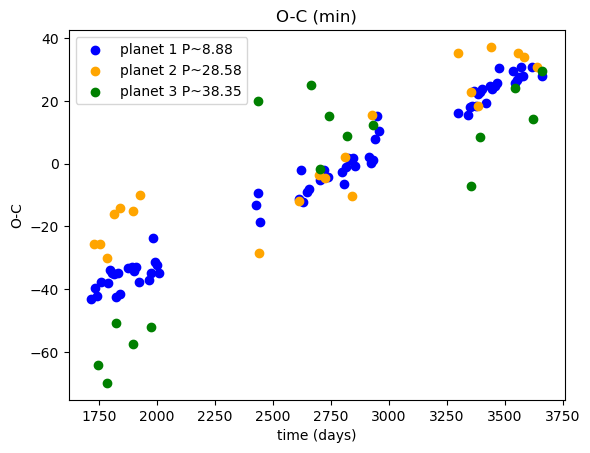

In [81]:
# TTV
ttv_1 = np.array(ttv_1)
ttv_2 = np.array(ttv_2)
ttv_3 = np.array(ttv_3)


plt.scatter(tc_chi_1, ttv_1*(24*60),c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

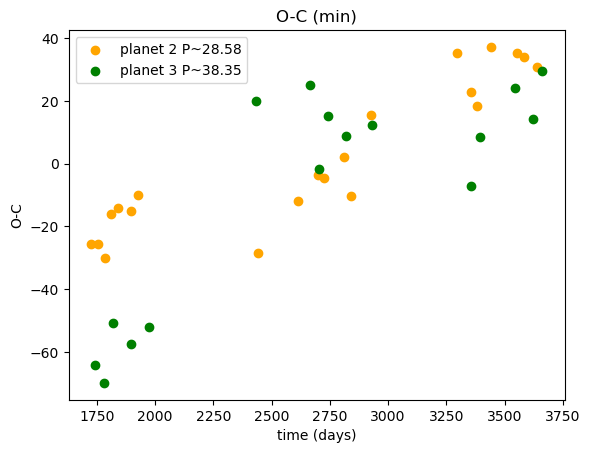

In [82]:
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

[-4.17312836e-03  6.49887019e-02 -6.62204631e+00 -3.47575756e-04]
[ 7.56451532e-03  6.43935801e-02 -4.53537727e+00 -1.32896598e-04]


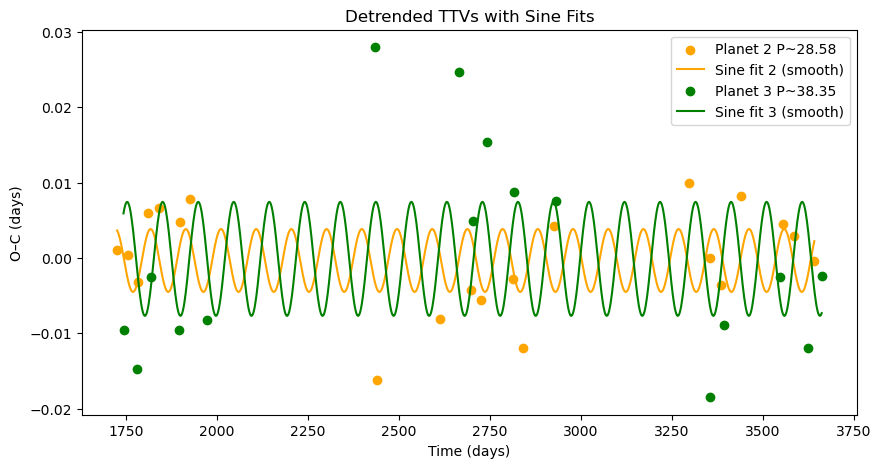

In [103]:
# Fit functions
def linear(x, a, b):
    return a * x + b

def sine(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset
# Fit and subtract for planet 2
popt_lin_2, _ = curve_fit(linear, tc_chi_2, ttv_2)
ttv_2_detrended = ttv_2 - linear(np.array(tc_chi_2), *popt_lin_2)

# Fit and subtract for planet 3
popt_lin_3, _ = curve_fit(linear, tc_chi_3, ttv_3)
ttv_3_detrended = ttv_3 - linear(np.array(tc_chi_3), *popt_lin_3)

# Initial guess: amplitude, frequency (rad/day), phase, offset
guess_2 = [0.01, 2 * np.pi / 100, 0, 0]
popt_sin_2, _ = curve_fit(sine, tc_chi_2, ttv_2_detrended, p0=guess_2)
print(popt_sin_2)

guess_3 = [0.03, 2 * np.pi / 100, 0, 0]
popt_sin_3, _ = curve_fit(sine, tc_chi_3, ttv_3_detrended, p0=guess_3)
print(popt_sin_3)

# Dense time arrays for smooth plots
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Detrended fits: only plot sine on linear-subtracted times
sine_fit_2 = sine(dense_time_2, *popt_sin_2)
sine_fit_3 = sine(dense_time_3, *popt_sin_3)

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended, color='orange', label=f'Planet 2 P~{round(planet_2_period.value, 3)}')
plt.plot(dense_time_2, sine_fit_2, 'orange', label='Sine fit 2 (smooth)')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended, color='green', label=f'Planet 3 P~{round(planet_3_period.value, 3)}')
plt.plot(dense_time_3, sine_fit_3, 'g', label='Sine fit 3 (smooth)')

plt.title('Detrended TTVs with Sine Fits')
plt.xlabel('Time (days)')
plt.ylabel('O–C (days)')
plt.legend()
plt.show()

[ 2.09174335e-05 -5.50543146e-02 -4.15305930e-03  1.76817337e-02
 -3.34066228e+00]
[ 3.07127666e-05 -8.81892297e-02 -9.35891887e-03  1.69831026e-02
 -4.41473634e+00]


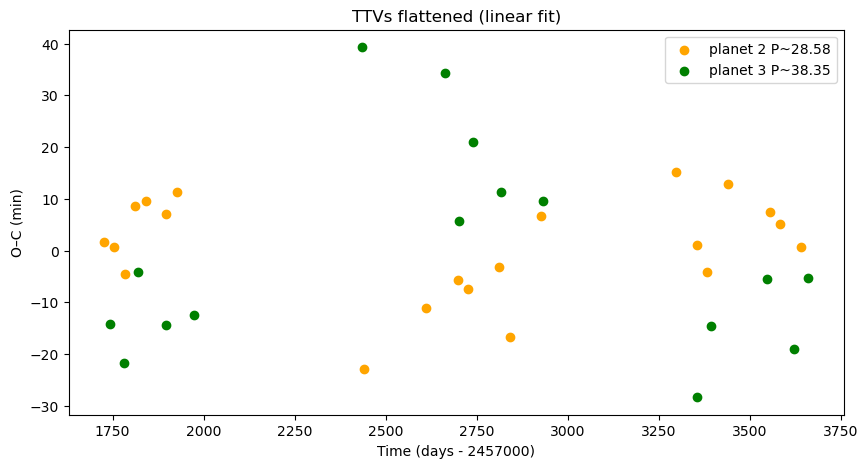

In [107]:
def linear_sine(t, a, b, A, omega, phase):
    return a * t + b + A * np.sin(omega * t + phase)

# Convert TTVs to minutes
ttv_2_min = np.array(ttv_2)
ttv_3_min = np.array(ttv_3) 

# Initial guesses: [slope, intercept, amplitude, omega, phase]
guess_2 = [28, 0, 0.01, 0.5*3.26255812e-02, 0]
guess_3 = [38, 0, 0.05, 0.5*3.05795071e-02, 0]

# Fit for planet 2
popt_2, _ = curve_fit(linear_sine, tc_chi_2, ttv_2_min, p0=guess_2)

# Fit for planet 3
popt_3, _ = curve_fit(linear_sine, tc_chi_3, ttv_3_min, p0=guess_3)

print(popt_2)
print(popt_3)

def linear_only(t, a, b):
    return a * t + b

ttv_2_detrended = ttv_2_min - linear_only(np.array(tc_chi_2), *popt_2[:2])
ttv_3_detrended = ttv_3_min - linear_only(np.array(tc_chi_3), *popt_3[:2])

# Dense time arrays for smooth curves
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Full model predictions
fit_2_full = linear_sine(dense_time_2, *popt_2)
fit_3_full = linear_sine(dense_time_3, *popt_3)

# Sine-only on detrended
fit_2_sine = fit_2_full - linear_only(dense_time_2, *popt_2[:2])
fit_3_sine = fit_3_full - linear_only(dense_time_3, *popt_3[:2])

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended*24*60, color='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
# plt.plot(dense_time_2, fit_2_sine, 'orange', label='Sine fit 2')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended*24*60, color='green', label=f'planet 3 P~{round(planet_3_period.value,3)}')
# plt.plot(dense_time_3, fit_3_sine, 'g', label='Sine fit 3')

plt.title('TTVs flattened (linear fit)')
plt.xlabel(f'Time (days - {TESS_offset})')
plt.ylabel('O–C (min)')
plt.legend()
plt.show()

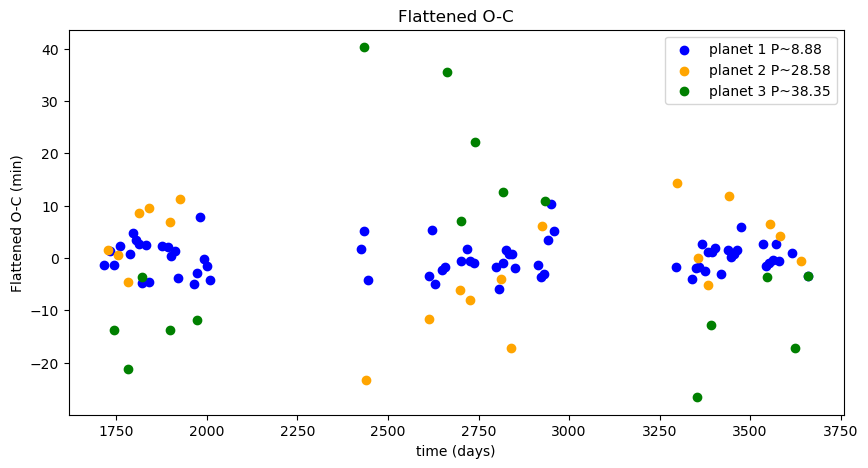

In [106]:
# Fit a linear function to the TTV data
coeffs_1 = np.polyfit(tc_chi_1, ttv_1*(24*60), 1)
linear_fit_1 = np.polyval(coeffs_1, tc_chi_1)

coeffs_2 = np.polyfit(tc_chi_2, ttv_2*(24*60), 1)
linear_fit_2 = np.polyval(coeffs_2, tc_chi_2)

coeffs_3 = np.polyfit(tc_chi_3, ttv_3*(24*60), 1)
linear_fit_3 = np.polyval(coeffs_3, tc_chi_3)

# Subtract the linear fit from the TTV data
ttv_1_detrended = ttv_1*(24*60) - linear_fit_1
ttv_2_detrended = ttv_2*(24*60) - linear_fit_2
ttv_3_detrended = ttv_3*(24*60) - linear_fit_3


plt.figure(figsize=(10, 5))
# Plot the detrended data
plt.scatter(tc_chi_1, ttv_1_detrended,c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2_detrended,c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3_detrended,c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (min)')
plt.legend()
plt.show()

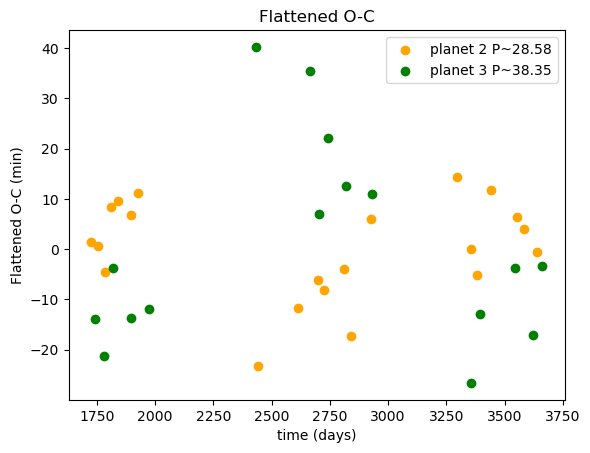

In [78]:
plt.scatter(tc_chi_2, ttv_2_detrended,c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3_detrended,c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (min)')
plt.legend()
plt.show()

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert to minutes
ttv_1_minutes = ttv_1 * 24 * 60

# Sine + linear model
def model(t, a, b, A, P, phi):
    return a * t + b + A * np.sin(2 * np.pi * t / P + phi)

# Initial guesses
# Guess P (period) from visual estimate (e.g., ~100 days), adjust as needed
p0 = [0, np.mean(ttv_1_minutes), 1, 100, 0]  

# Fit the model
params, _ = curve_fit(model, tc_chi_1, ttv_1_minutes, p0=p0, maxfev=10000)

# Extract fit values
a, b, A, P, phi = params

# Generate fitted curve
t_fit = np.linspace(min(tc_chi_1), max(tc_chi_1), 1000)
ttv_fit = model(t_fit, a, b, A, P, phi)

# # Plot data and fit
# plt.scatter(tc_chi_1, ttv_1_minutes, label='planet 1 data')
# plt.plot(t_fit, ttv_fit, color='red', label='fit: linear + sinusoid', linewidth=2)
# plt.title('TTV Fit: Linear + Sinusoid')
# plt.xlabel('time (days)')
# plt.ylabel('O-C (min)')
# plt.legend()
# plt.show()

# # Print parameters
# print(f"""
# Fit Parameters:
#   Slope (a)      = {a:.5f} min/day
#   Intercept (b)  = {b:.5f} min
#   Amplitude (A)  = {A:.5f} min
#   Period (P)     = {P:.2f} days
#   Phase (phi)    = {phi:.2f} rad
# """)


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert to minutes
ttv_2_minutes = ttv_2 * 24 * 60

# Sine + linear model
def model(t, a, b, A, P, phi):
    return a * t + b + A * np.sin(2 * np.pi * t / P + phi)

# Initial guesses
# Guess P (period) from visual estimate (e.g., ~100 days), adjust as needed
p0 = [0, np.mean(ttv_2_minutes), 1, 100, 0]  

# Fit the model
params, _ = curve_fit(model, tc_chi_2, ttv_2_minutes, p0=p0, maxfev=10000)

# Extract fit values
a, b, A, P, phi = params

# Generate fitted curve
t_fit_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
ttv_fit_2 = model(t_fit, a, b, A, P, phi)

# Plot data and fit
# plt.scatter(tc_chi_2, ttv_2_minutes, label='planet 1 data')
# plt.plot(t_fit_2, ttv_fit_2, color='red', label='fit: linear + sinusoid', linewidth=2)
# plt.title('TTV Fit: Linear + Sinusoid')
# plt.xlabel('time (days)')
# plt.ylabel('O-C (min)')
# plt.legend()
# plt.show()

# Print parameters
# print(f"""
# Fit Parameters:
#   Slope (a)      = {a:.5f} min/day
#   Intercept (b)  = {b:.5f} min
#   Amplitude (A)  = {A:.5f} min
#   Period (P)     = {P:.2f} days
#   Phase (phi)    = {phi:.2f} rad
# """)


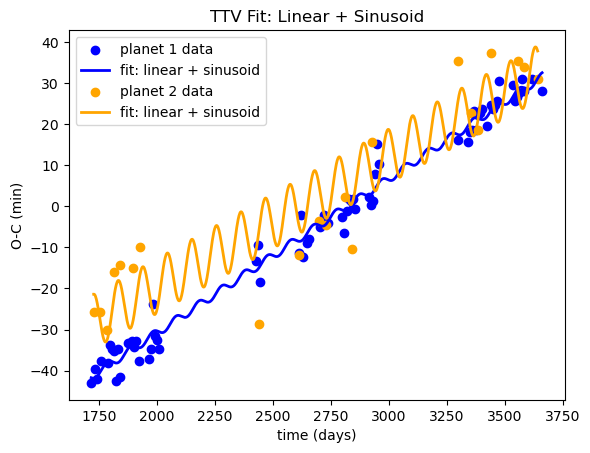

In [77]:
# Plot data and fit
plt.scatter(tc_chi_1, ttv_1_minutes, c='blue',label='planet 1 data')
plt.plot(t_fit, ttv_fit, color='blue', label='fit: linear + sinusoid', linewidth=2)

# Plot data and fit
plt.scatter(tc_chi_2, ttv_2_minutes,c='orange', label='planet 2 data')
plt.plot(t_fit_2, ttv_fit_2, color='orange', label='fit: linear + sinusoid', linewidth=2)
plt.title('TTV Fit: Linear + Sinusoid')
plt.xlabel('time (days)')
plt.ylabel('O-C (min)')
plt.legend()
plt.show()